# Outlier Patch Detection on TR1 Data

Applies the per-patch amplitude perturbation analysis from `outlier_patch_test.ipynb`
to the first TR1 shear map (`SHE-1`).  The 48-patch tile mask serves as both the
patch decomposition and the jackknife regions.

In [148]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

import heracles
import heracles.healpy
import heracles.dices as dices

## 1. Load catalog and build shear maps

We read `23405.fits` with `heracles.FitsCatalog` and select tomographic bin 1.
The shear (SHE) and weight (WHT) maps are produced by `heracles.map_catalogs`
using the LensMC ellipticity columns (`she_lensmc_e1/e2/weight`).

In [149]:
from heracles.core import update_metadata

DATA_DIR  = "tr1_data"
CAT_FILE  = f"{DATA_DIR}/23405.fits" #25348 or 23405

nside     = 1024
lmax_data = 2000   # pseudo-Cl transform lmax
lmax_mask = 3000   # mask transform lmax (naturalspice accuracy)
lmax_out  = 1500   # unmixed Cl output lmax
lmin      = 300    # minimum l for analysis
nlbins     = 10    # number of logarithmic bins for plotting
method = "metacal"  # "metacal" or "lensmc" (shear estimator)

# Visibility mask — restrict to southern patch (Dec < -43 deg, the larger component)
mask = hp.read_map("/home/jaimerzp/Documents/software/heracles/examples/tr1_data/tr1_mask.fits")
#nside_mask = hp.npix2nside(len(mask))
#ipix_all   = np.arange(len(mask))
#theta_all, _ = hp.pix2ang(nside_mask, ipix_all)
#dec_all    = 90.0 - np.degrees(theta_all)
#south_pix  = dec_all < -43.0        # isolate the southern patch
#mask       = np.where(south_pix, mask, 0.0)

# Load catalog and select tomographic bin 1 (LensMC shear estimator)
catalog  = heracles.FitsCatalog(CAT_FILE)
catalog.visibility = mask
catalogs = {1: catalog}

# Data mapper: SHE/WHT transforms for pseudo-Cl computation
mapper_data = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_data)
# Mask mapper: WHT transforms for naturalspice (higher lmax for real-space accuracy)
mapper_mask = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_mask)

fields_map = {
    "SHE": heracles.Shears(
        mapper_data,
        "right_ascension",
        "declination",
        f"she_{method}_e1",
        f"-she_{method}_e2",
        f"she_{method}_weight",
        mask="WHT",
    ),
}
fields_mask = {
    "WHT": heracles.Weights(
        mapper_mask,
        "right_ascension",
        "declination",
        f"she_{method}_weight",
    ),
}

she_maps = heracles.map_catalogs(fields_map, catalogs)
wht_maps = heracles.map_catalogs(fields_mask, catalogs)

# Apply mask
#for field in she_maps:
#    she_maps[field] *= mask
#for field in wht_maps:
#    wht_maps[field] *= mask


## 2. Build the patch segmentation map

We divide the survey footprint into roughly 20-sq-deg patches using
`skysegmentor.segmentmapN` on the WHT weight map.

In [150]:
import skysegmentor

# Target ~20 sq deg per patch
b = she_maps[("SHE", 1)].dtype.metadata["bias"]
fsky      = (mask).sum() / hp.nside2npix(nside)
area_deg2 = fsky * 4 * np.pi * (180 / np.pi) ** 2
n_patches = max(1, round(area_deg2 / 20))
print(f"Survey area: {area_deg2:.1f} sq deg  →  {n_patches} patches of ~{area_deg2/n_patches:.1f} sq deg each")

# skysegmentor returns an integer map with labels 1..n_patches
jkmap = skysegmentor.segmentmapN(mask, n_patches)
print(f"jkmap unique labels: {np.unique(jkmap[jkmap > 0]).astype(int)}")


Survey area: 504.5 sq deg  →  25 patches of ~20.2 sq deg each
jkmap unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


Footprint centre: RA=63.7°, Dec=-40.0°
Footprint extent: ΔRA≈163.9°, ΔDec≈145.5°


/tmp/ipykernel_84880/306898918.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon_c, lat_c = float(lon_c), float(lat_c)
/tmp/ipykernel_84880/306898918.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


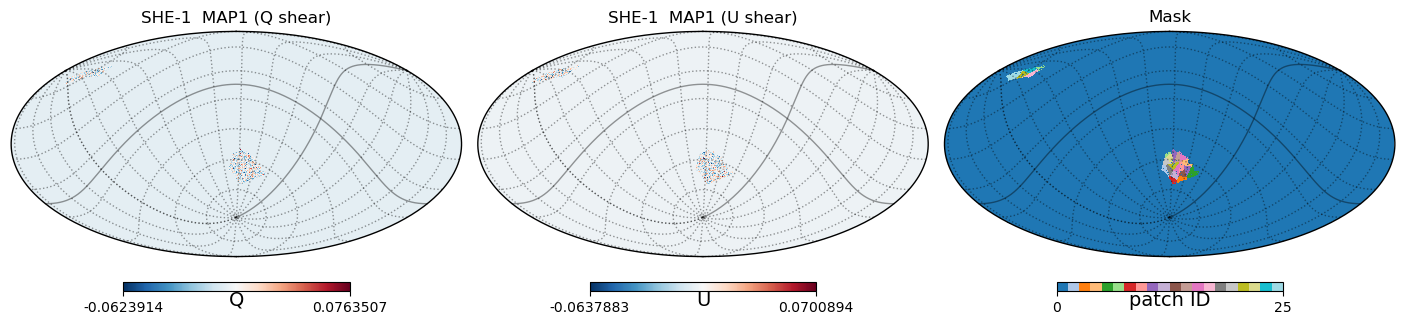

In [151]:
# ── Diagnostic: SHE-1 map and patch regions ──
footprint_pix = np.where(she_maps_all["lensmc"][("SHE", 1)][0] != 0)[0]
vec = np.array(hp.pix2vec(nside, footprint_pix))
centre_vec = vec.mean(axis=1)
centre_vec /= np.linalg.norm(centre_vec)
lon_c, lat_c = hp.vec2ang(centre_vec, lonlat=True)
# vec2ang returns arrays even for a single vector — extract scalars for rot
lon_c, lat_c = float(lon_c), float(lat_c)
print(f"Footprint centre: RA={lon_c:.1f}°, Dec={lat_c:.1f}°")

thetas, phis = hp.pix2ang(nside, footprint_pix)
dec_deg = 90 - np.degrees(thetas)
ra_deg  = np.degrees(phis)
ew_deg  = ra_deg.max() - ra_deg.min()
ns_deg  = dec_deg.max() - dec_deg.min()
print(f"Footprint extent: ΔRA≈{ew_deg:.1f}°, ΔDec≈{ns_deg:.1f}°")

xsize = 800
reso  = max(ew_deg, ns_deg) * 60 / (xsize / 2)

fig = plt.figure(figsize=(14, 5))

hp.mollview(
    she_maps_all["lensmc"][("SHE", 1)][0], fig=fig, sub=(1, 3, 1),
    rot=(lon_c, lat_c, 0), #reso=reso, xsize=xsize,
    title="SHE-1  MAP1 (Q shear)", unit="Q",
    cmap="RdBu_r", notext=True,
)
hp.mollview(
    she_maps_all["lensmc"][("SHE", 1)][1], fig=fig, sub=(1, 3, 2),
    rot=(lon_c, lat_c, 0), #reso=reso, xsize=xsize,
    title="SHE-1  MAP1 (U shear)", unit="U",
    cmap="RdBu_r", notext=True,
)
hp.mollview(
    jkmap, fig=fig, sub=(1, 3, 3),
    rot=(lon_c, lat_c, 0), #reso=reso, xsize=xsize,
    title="Mask", unit="patch ID",
    cmap="tab20", notext=True,
)
hp.graticule(dpar=5, dmer=5, alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Heracles setup

In [152]:
# Per-patch and full-footprint naturalspice: SHE @ lmax_data, WHT @ lmax_mask
fields = {
    "SHE": heracles.Shears(mapper_data, mask="WHT"),
    "WHT": heracles.Weights(mapper_data),
}
print(f"Data mapper: nside={mapper_data.nside}, lmax={mapper_data.lmax}")
print(f"Mask mapper: nside={mapper_mask.nside}, lmax={mapper_mask.lmax}")

Data mapper: nside=1024, lmax=2000
Mask mapper: nside=1024, lmax=3000


## 4. Per-patch alms and pseudo-$C_\ell$

For each patch we:
1. Mask the shear and weight maps to that patch's pixels
2. Transform to alms
3. Compute the pseudo-$C_\ell$

In [153]:
import heracles.dices as dices

she = she_maps[("SHE", 1)]   # (2, npix) spin-2 shear map
wht = wht_maps[("WHT", 1)]   # (npix,) weight map

data_cls   = {}
mask_cls   = {}
shear_alms = []   # per-patch alms (summed for full-footprint below)
mask_alms  = []

for label in range(1, n_patches + 1):
    patch_mask = jkmap == label

    # 1. Mask maps to this patch
    she_p = she.copy(); she_p[:, ~patch_mask] = 0.0
    wht_p = wht.copy(); wht_p[~patch_mask]    = 0.0

    # 2. Update metadata: scale fsky and bias to this patch's sky fraction.
    # update_metadata() sets array.dtype in-place — the only way to preserve
    # numpy custom metadata (astype/np.array silently drop it).
    update_metadata(she_p, fsky=fsky/n_patches, bias=b/n_patches)

    # 3. Compute alms of each region
    shear_alm = mapper_data.transform(she_p)
    mask_alm  = mapper_mask.transform(wht_p)
    shear_alms.append(shear_alm)
    mask_alms.append(mask_alm)

    # 4. Compute pseudo-Cls of each region
    data_cls.update(heracles.angular_power_spectra({("SHE", label): shear_alm}))
    mask_cls.update(heracles.angular_power_spectra({("WHT", label): mask_alm}))

    if label % 5 == 0 or label == n_patches:
        print(f"  Patch {label}/{n_patches}", end=", ", flush=True)

print(f"Done — {n_patches} patches.")


  Patch 5/25,   Patch 10/25,   Patch 15/25,   Patch 20/25,   Patch 25/25, Done — 25 patches.


## 5. Unmix the Cls of each region

`naturalspice` divides the data correlation function by the mask correlation
function in real space, correcting for mode-mixing without an explicit
mixing-matrix inversion.

In [154]:
ledges = np.logspace(np.log10(lmin), np.log10(lmax_out), nlbins + 1)

In [155]:
print("Applying naturalspice to each patch...")
rcond = 0.01  # regularization for matrix inversion 
unmixed_cls    = heracles.naturalspice(data_cls, mask_cls, fields, rcond=0.7)
unmixed_binned = heracles.binned(unmixed_cls, ledges)
print("Done.")


Applying naturalspice to each patch...
Done.


## 6. Full-footprint $C_\ell$ and sample covariance

The full-footprint alm is the sum of per-patch alms (SHT linearity — no extra SHTs).
The covariance is the **sample covariance** of the per-region unmixed Cls,
characterising region-to-region scatter.

In [156]:
# Full-footprint alms — transform the full masked map directly
she_full = she_maps[("SHE", 1)]
wht_full = wht_maps[("WHT", 1)]

alm_full_shear = mapper_data.transform(she_full)
alm_full_mask  = mapper_mask.transform(wht_full)

full_data_cls = heracles.angular_power_spectra({("SHE", "full"): alm_full_shear})
full_mask_cls = heracles.angular_power_spectra({("WHT", "full"): alm_full_mask})

print("Applying naturalspice to full footprint...")
full_unmixed   = heracles.naturalspice(full_data_cls, full_mask_cls, fields, rcond=rcond)
full_unmixed_b = heracles.binned(full_unmixed, ledges)
print("Done.")

KEY        = ("SHE", "SHE", "full", "full")
ell_full   = full_unmixed_b[KEY].ell
fac_full   = ell_full
cl_full_ee = np.array(full_unmixed_b[KEY][0, 0])
cl_full_bb = np.array(full_unmixed_b[KEY][1, 1])
nlbins     = len(ell_full)

# Sample covariance of per-region unmixed Cls
cls_patches_ee = np.array([
    np.array(unmixed_binned[("SHE", "SHE", label, label)][0, 0])
    for label in range(1, n_patches + 1)
])
cls_patches_bb = np.array([
    np.array(unmixed_binned[("SHE", "SHE", label, label)][1, 1])
    for label in range(1, n_patches + 1)
])

cov_ee = np.cov(cls_patches_ee.T)
cov_bb = np.cov(cls_patches_bb.T)

err_ee = np.sqrt(np.diag(cov_ee) / n_patches)
err_bb = np.sqrt(np.diag(cov_bb) / n_patches)

print(f"Covariance rank: {np.linalg.matrix_rank(cov_ee)}  (nlbins={nlbins}, n_patches={n_patches})")


Applying naturalspice to full footprint...
Done.
Covariance rank: 10  (nlbins=10, n_patches=25)


## 6. Per-patch Cls plot

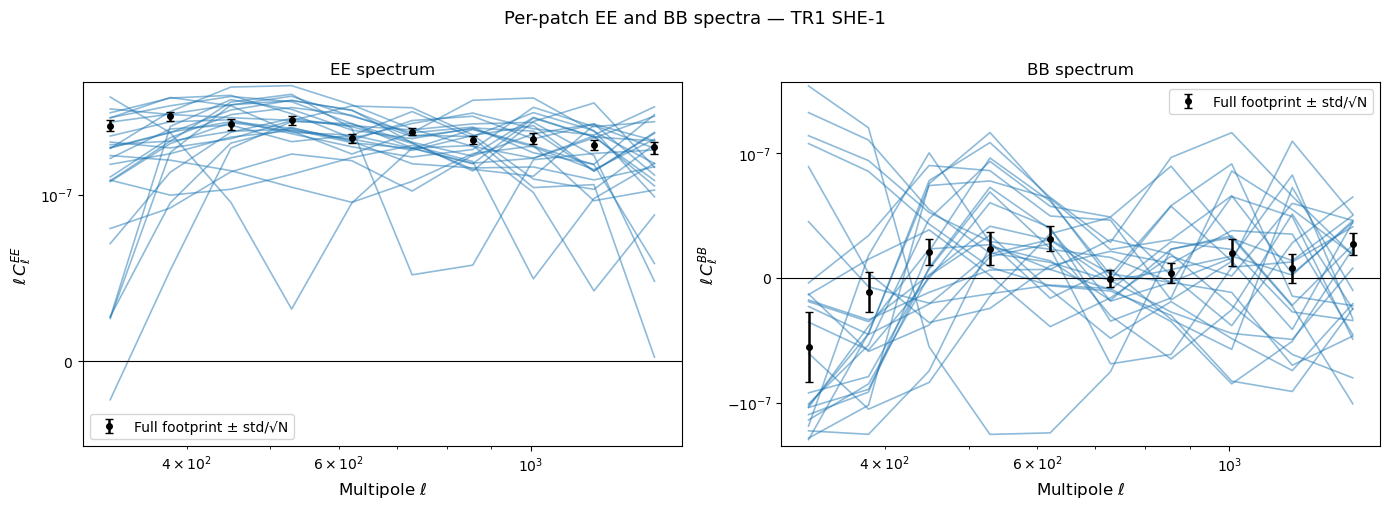

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for component, comp_idx, err, ax in [
    ("EE", (0, 0), err_ee, axes[0]),
    ("BB", (1, 1), err_bb, axes[1]),
]:
    for label in range(1, n_patches + 1):
        key   = ("SHE", "SHE", label, label)
        cl_c  = unmixed_binned[key][comp_idx[0], comp_idx[1]]
        ell_b = unmixed_binned[key].ell
        ax.plot(ell_b, ell_b * cl_c, color="C0", lw=1.2, alpha=0.5)

    cl_full = full_unmixed_b[KEY][comp_idx[0], comp_idx[1]]
    ax.errorbar(ell_full, ell_full * np.array(cl_full),
                yerr=ell_full * err,
                fmt="ko", ms=4, lw=1.8, capsize=3, zorder=10,
                label="Full footprint ± std/√N")

    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
    ax.set_ylabel(r"$\ell\,C_\ell^{" + component + r"}$", fontsize=12)
    ax.set_xscale("log")
    ax.set_title(f"{component} spectrum", fontsize=12)
    ax.set_yscale("symlog", linthresh=1e-7)
    ax.legend(fontsize=10)

plt.suptitle("Per-patch EE and BB spectra — TR1 SHE-1", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 7. Leave-one-out $\chi^2$ outlier test

For each patch $k$ we compare its decoupled $C_\ell^{EE}$ to the mean of all
**other** patches:
$$\mu_{{-k}} = \frac{{1}}{{N-1}}\sum_{{j\neq k}} C_\ell^{{EE,j}}$$

The leave-one-out (LOO) $\chi^2$ is the Mahalanobis distance using the
covariance estimated from those same $N-1$ patches, so the outlier cannot
inflate its own reference or covariance.  Bins with $\ell < \ell_{{\min}}$
are excluded.

In [158]:
from scipy.stats import chi2 as chi2_dist

# Per-patch EE Cls, shape (n_patches, nlbins)
cls_patches = np.array([
    np.array(unmixed_binned[("SHE", "SHE", label, label)][0, 0])
    for label in range(1, n_patches + 1)
])

# Crop to ell >= lmin
chi2_mask = ell_full >= lmin
cls_chi2  = cls_patches[:, chi2_mask]
N = n_patches
p = int(chi2_mask.sum())
print(f"Using {p} ell bins with ell >= {lmin}")

# Leave-one-out chi2: covariance estimated from the remaining N-1 patches
# so the outlier cannot inflate its own reference or covariance.
chi2_loo = np.zeros(N)
for k in range(N):
    idx_rest   = [j for j in range(N) if j != k]
    cls_rest   = cls_chi2[idx_rest]
    mu_loo     = cls_rest.mean(axis=0)
    cov_loo    = np.cov(cls_rest.T)
    diff       = cls_chi2[k] - mu_loo
    chi2_loo[k] = diff @ np.linalg.inv(cov_loo) @ diff

thresh_99 = chi2_dist.ppf(0.99, df=p)

print()
print(f"{'Patch':>6}  {'chi2':>10}  {'chi2 / nlbins':>9}")
print("-" * 32)
for k in range(N):
    outlier = "  <- OUTLIER" if chi2_loo[k] > thresh_99 else ""
    print(f"  {k+1:3d}    {chi2_loo[k]:10.2f}   {chi2_loo[k]/p:7.2f}{outlier}")


Using 10 ell bins with ell >= 300

 Patch        chi2  chi2 / nlbins
--------------------------------
    1         12.60      1.26
    2         15.73      1.57
    3         39.46      3.95  <- OUTLIER
    4         10.40      1.04
    5         17.11      1.71
    6          9.06      0.91
    7         56.83      5.68  <- OUTLIER
    8          6.72      0.67
    9         14.42      1.44
   10          9.24      0.92
   11         11.66      1.17
   12         75.99      7.60  <- OUTLIER
   13         17.29      1.73
   14         16.45      1.64
   15         10.65      1.07
   16         31.74      3.17  <- OUTLIER
   17          8.97      0.90
   18         28.94      2.89  <- OUTLIER
   19         17.16      1.72
   20         23.10      2.31
   21         11.17      1.12
   22         38.93      3.89  <- OUTLIER
   23          8.75      0.87
   24         28.61      2.86  <- OUTLIER
   25          6.56      0.66


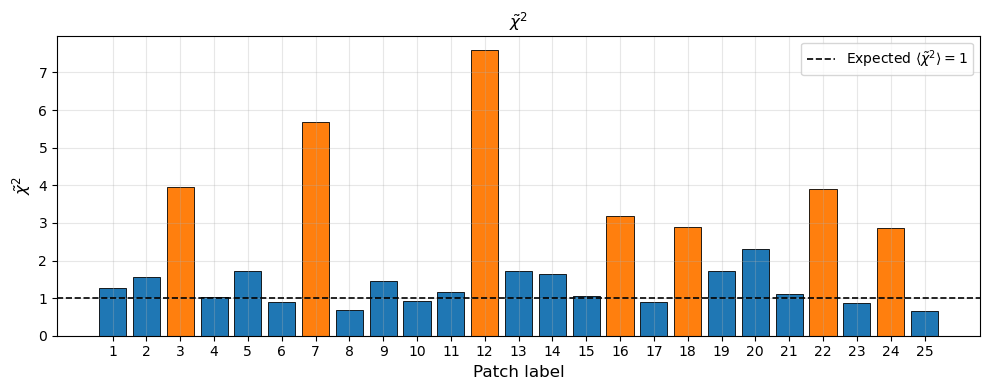

In [159]:
fig, ax = plt.subplots(figsize=(max(10, n_patches // 3), 4))

colors = ["C1" if chi2_loo[k] > thresh_99 else "C0" for k in range(N)]
ax.bar(range(1, N + 1), chi2_loo/nlbins, color=colors, edgecolor="k", linewidth=0.6)

ax.axhline(1,         color="k",  ls="--", lw=1.2,
           label=rf"Expected $\langle \tilde{{\chi}}^2\rangle = 1$")

ax.set_xlabel("Patch label", fontsize=12)
ax.set_ylabel(r"$\tilde{\chi}^2$", fontsize=12)
ax.set_xticks(range(1, N + 1))
ax.set_title(
    r"$\tilde{\chi}^2$",
    fontsize=12,
)
#ax.set_yscale("log")
ax.legend(fontsize=10)
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_84880/411122380.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon_c, lat_c  = float(lon_c), float(lat_c)


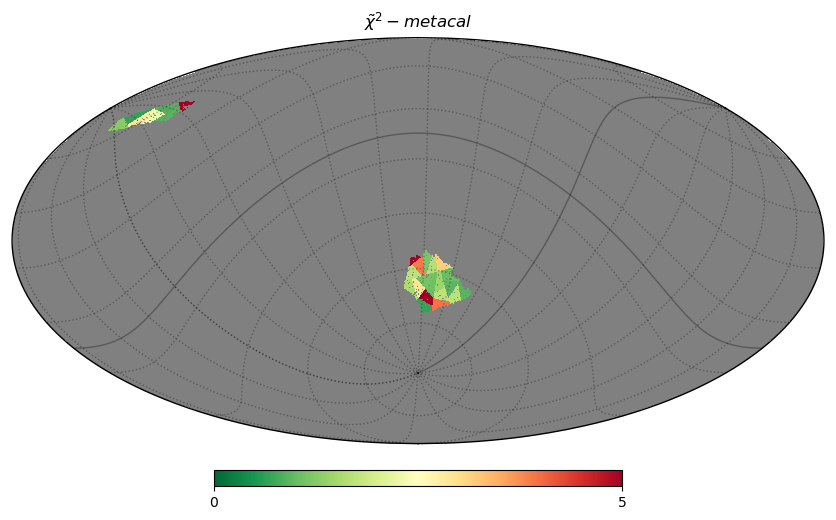

In [160]:
# Sky map coloured by chi2_loo / thresh_99 — values > 1 are outliers
sky_chi2 = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
for k in range(N):
    sky_chi2[jkmap == k + 1] = chi2_loo[k] / nlbins

footprint_pix = np.where(jkmap > 0)[0]
vec           = np.mean(np.stack(hp.pix2vec(nside, footprint_pix), axis=1), axis=0)
lon_c, lat_c  = hp.vec2ang(vec / np.linalg.norm(vec), lonlat=True)
lon_c, lat_c  = float(lon_c), float(lat_c)

hp.mollview(
    sky_chi2,
    rot=(lon_c, lat_c, 0),
    title=rf"$\tilde{{\chi}}^2 - {method}$",
    cmap="RdYlGn_r",
    min=0, max=5,
    notext=True,
)
hp.graticule(dpar=5, dmer=5, alpha=0.3)
plt.show()


<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_84880/3270255096.py:36: SyntaxWarning: invalid escape sequence '\s'
  f"(C1 = above 99% threshold, grey bands: 1$\sigma$ / 2$\sigma$)",


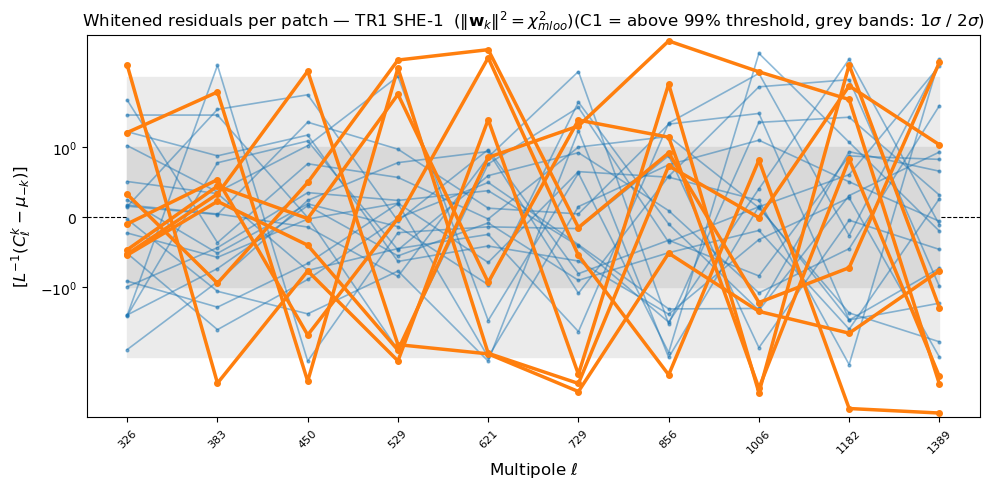

In [161]:
# ── Whitened residuals: L^{-1} (C_ell^k - mu_{-k}), all patches overplotted ─
# L is the Cholesky factor of the leave-one-out covariance.
# Each component is ~N(0,1) under the null; ||w_k||^2 = chi2_loo[k].

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(0, color="k", lw=0.8, ls="--", zorder=0)
ax.fill_between(range(p), -1, 1, color="0.85", zorder=1, label=r"$1\sigma$")
ax.fill_between(range(p), -2, 2, color="0.92", zorder=0, label=r"$2\sigma$")

for k in range(N):
    idx_rest = [j for j in range(N) if j != k]
    cls_rest = cls_chi2[idx_rest]
    mu_loo   = cls_rest.mean(axis=0)
    cov_loo  = np.cov(cls_rest.T)
    L        = np.linalg.cholesky(cov_loo)
    w        = np.linalg.solve(L, cls_chi2[k] - mu_loo)

    is_outlier = chi2_loo[k] > thresh_99
    color  = "C1" if is_outlier else "C0"
    zorder = 5 if is_outlier else 2
    alpha  = 1.0 if is_outlier else 0.5
    lw     = 2.5 if is_outlier else 1.2
    label  = f"Patch {k+1} (outlier)" if is_outlier else ("Good patches" if k == 0 else None)
    ax.plot(range(p), w, color=color, lw=lw, alpha=alpha,
            marker="o", ms=4 if is_outlier else 2,
            zorder=zorder, label=label)

ax.set_xticks(range(p))
ax.set_xticklabels([f"{l:.0f}" for l in ell_full[chi2_mask]], rotation=45, fontsize=8)
ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$[L^{{-1}}(C_\ell^k - \mu_{{-k}})]$", fontsize=12)
ax.set_title(
    r"Whitened residuals per patch — TR1 SHE-1"
    r"  ($\|\mathbf{w}_k\|^2 = \chi^2_{{m loo}}$)"
    f"(C1 = above 99% threshold, grey bands: 1$\sigma$ / 2$\sigma$)",
    fontsize=12,
)
ax.set_yscale("symlog", linthresh=2)
plt.tight_layout()
plt.show()
